In [ ]:
# =============================================================================
# MIT License
#
# Copyright (c) 2025 Jason Coleman
# UF MBI Microscopy Core / NeuroMicroscopy Co-op
# University of Florida
# jcoleman@ufl.edu
#
# Permission is hereby granted, free of charge, to any person obtaining a copy
# of this software and associated documentation files (the "Software"), to deal
# in the Software without restriction, including without limitation the rights
# to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
# copies of the Software, and to permit persons to whom the Software is
# furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in all
# copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
# AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
# OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
# SOFTWARE.
# =============================================================================

# Notebook: image_hist&qc_scanimage_TCXY.ipynb
# Version: 0.0.1
# Date: 2026-02-11

# Description:
#   Processing of 2 2-channel ScanImage TIFF ZT (timelapse) stacks to interactively plot and inspect image data
#       (e.g., histograms and quality-control metrics)


# Changelog:
#   0.0.1 (2026-02-11) – Modified from get_tif_info_scanimage.ipynb
#   0.1.0 (2026-02-17) – Added meta-data extraction and spectral analysis for frame drift etc
  
# NOTE: This code is intended for research and educational use.
# Please cite or acknowledge the UF MBI Microscopy Core where appropriate.

# **License:** MIT  
# © 2026 Jason Coleman, UF MBI Microscopy Core / NeuroMicroscopy Co-op  
# University of Florida — jcoleman@ufl.edu


In [99]:
# Import ScanImage tif files (single-file)

# Works for T- or Z-only stacks

import numpy as np
import os
from pathlib import Path
import json
import socket
import tifffile # !pip install tifffile
import platform
import re
from datetime import datetime
import matplotlib.pyplot as plt

import pandas as pd

# Path to your ScanImage stack (replace 'text' with your directory
# path = '/Users/jcoleman/Documents/--LARGE DATA--/#VonRoemeling/ZT20 TIFs'
path = '/Users/jcoleman/Documents/--LARGE DATA--/#VonRoemeling'

# Name of the TIF file to import
# tif_filename1 = 'ZT20_25x_930_t0_area1_00001.tif' #'ZT20_25x_930_t5_area1_00001.tif'
# tif_filename1 = 'ZT20_25x_930_t5_area2_00001.tif'
# tif_filename2 = 'ZT20_25x_1100_t5_area2_00001.tif' #'ZT20_25x_1100_t5_area1_00001.tif'
# tif_filename2 = 'ZT20_25x_1100_t5_area1_00001.tif'
tif_filename1 = 'T1800_25x3x_930nm_area07_00001.tif' # (T,C,X,Y)
tif_filename2 = 'T1800_25x3x_1100nm_area07_00001.tif' # (T,C,X,Y)

tif_file1 = os.path.join(
    path, 
    tif_filename1
)
tif_file2 = os.path.join(
    path, 
    tif_filename2
)

tif_data1 = tifffile.imread(tif_file1)
tif_data2 = tifffile.imread(tif_file2)

print(f'Pathname: {path}')
print(f'Filenames: {tif_filename1} | {tif_filename2}')
print(f'File1 shape: (e.g. T, C, Y, X): {tif_data1.shape}')
print(f'File2 shape: (e.g. T, C, Y, X): {tif_data2.shape}')

# NEXT STEPS - Run the next cell for 2-channel ZT data OR skip it and run the one after for T data


Pathname: /Users/jcoleman/Documents/--LARGE DATA--/#VonRoemeling
Filenames: T1800_25x3x_930nm_area07_00001.tif | T1800_25x3x_1100nm_area07_00001.tif
File1 shape: (e.g. T, C, Y, X): (1800, 2, 512, 512)
File2 shape: (e.g. T, C, Y, X): (1800, 2, 512, 512)


In [100]:
# Read in Channel1 (green) and Channel2 (red) from 2 TIF files, recombine for green-red
# import tifffile as tiff
# import numpy as np

def load_tcyx(path):
    data = tiff.imread(path)
    if data.ndim != 4:
        raise ValueError(f"Expected 4D (T,C,Y,X) but got {data.shape}")
    return data

def recombine_ch1_ch2(tif1_ch1, tif2_ch2, filename=None):
    if tif1_ch1.shape != tif2_ch2.shape:
        msg = (
            f"SKIP: shape mismatch "
            f"Ch1 {tif1_ch1.shape} vs Ch2 {tif2_ch2.shape}"
        )
        if filename:
            msg += f" | file={filename}"
        print(msg)
        return None  # sentinel → skip downstream

    return np.stack([tif1_ch1, tif2_ch2], axis=2)  # (T,2,Y,X)

# tif1 = load_tcyx(tif_file1)  # (Z,T,C,Y,X)
# tif2 = load_tcyx(tif_file2)  # (Z,T,C,Y,X)

# Extract desired channels
tif1_ch1 = tif_data1[:, 0, :, :]   # (Z,T,Y,X)
tif2_ch2 = tif_data2[:, 1, :, :]   # (Z,T,Y,X)
# tif2_ch2 = tif2[0:11, :, 1, :, :]   # mismatch for ch1-ch2 Z-correlation tests (Z,T,Y,X)

# # Validate shape compatibility
# if tif1_ch1.shape != tif2_ch2.shape:
#     raise ValueError(f"Shape mismatch: {tif1_ch1.shape} vs {tif2_ch2.shape}")

# # Recombine into new "tif_data" with 2 channels
# tif_data = np.stack([tif1_ch1, tif2_ch2], axis=2)  # (Z,T,C,Y,X)
# tif_data = recombine_ch1_ch2(tif1_ch1, tif2_ch2, filename=tif_file1)

# if tif_data is None:
#     # Optionally log this somewhere
#     skipped_files.append(tif_file1)
#     skip_log.append({
#         "file_ch1": tif1_path,
#         "file_ch2": tif2_path,
#         "shape_ch1": tif1_ch1.shape,
#         "shape_ch2": tif2_ch2.shape,
#         "reason": "Z/T/Y/X mismatch"
#     })
#     return  # move to next file
skipped_files = []
skip_log = []
tif_data = recombine_ch1_ch2(tif1_ch1, tif2_ch2)

if tif_data is None:
    skipped_files.append(path)
    skip_log.append({
        "file_ch1": tif_file1,
        "file_ch2": tif_file2,
        "shape_ch1": tif1_ch1.shape,
        "shape_ch2": tif2_ch2.shape,
        "reason": "T/Y/X mismatch"
    })

    print(skipped_files)
    print(skip_log)
else:
    print("FUTURE: run_qc(tif_data)")

    # Now your existing QC code works as-is
    tif_data = np.transpose(tif_data, (0, 2, 1, 3))  # (T,C,Y,X)
    T, C, Y, X = tif_data.shape
    print(T,C,X,Y)
    print(f'Ch1 from {tif_filename1} + Ch2 from {tif_filename2} combined into single tif_data')

FUTURE: run_qc(tif_data)
1800 2 512 512
Ch1 from T1800_25x3x_930nm_area07_00001.tif + Ch2 from T1800_25x3x_1100nm_area07_00001.tif combined into single tif_data


In [101]:
# Average across T for every Z
    # (Eg for ZT20*.tif file, 20 T frames will be averaged into a single plane/2D image at each Z)
    # Calculate the average intensity for each Z-plane (17 total)
    # across all time frames (20 total) per plane.
    # Formula: Z_avg[i] = mean(Frames[i, 0:20])

    # Process: Z-Average Projection
    # Input:  (Z=17, T=20, Y, X)
    # Output: (Z=17, Y, X) 
    # Expression: Avg_Zi = Σ(T_0...T_19) / 20


# tif_Zavg = tif_data.mean(axis=1)  # (Z, C, Y, X)
# print(tif_Zavg.shape)

# T, C, Y, X = tif_data.shape
bin_size = 1 # number of T frames to average (30 would go from ~30fps to ~1fps)
T_trim = (T // bin_size) * bin_size
# tif_trim = tif_data[:T_trim, :, :, :]
# print(tif_trim.shape)

# tslice_middle = int(len(tif_trim)/2)
# tsliceNum = tslice_middle
# print(f"Plot Z-slice#: {tsliceNum}")
# T_trim

tif_binned = tif_data.reshape(
    T_trim // bin_size,
    bin_size,
    C,
    Y,
    X
).mean(axis=1)

print(f'Bin size: {bin_size}')
print(f'Original frame#: {T}')
print(f'New binned TIF shape (T,C,X,Y): {tif_binned.shape}')

tslice_middle = int(len(tif_binned)/2)
tsliceNum = tslice_middle
print(f"Plot T-frame#: {tsliceNum}")

Bin size: 1
Original frame#: 1800
New binned TIF shape (T,C,X,Y): (1800, 2, 512, 512)
Plot T-frame#: 900


In [102]:
# Z data averaged over T (e.g. (Z,C,Y,X))
# use for Z T-avg'ed data (ie Avg_Zi = Σ(T_0...T_19) / 20)

channel_1_data = tif_binned[:, 0, :, :]  # shape: (33, 512, 512)
channel_2_data = tif_binned[:, 1, :, :]  # shape: (33, 512, 512)

print(f"Channel 1   shape: {channel_1_data.shape}")
print(f"Channel 2   shape: {channel_2_data.shape}")

# Transpose to (Y, X, Z) if needed for your code
channel_1_data = np.transpose(channel_1_data, (1, 2, 0))  # shape: (512, 512, 33)
channel_2_data = np.transpose(channel_2_data, (1, 2, 0))  # shape: (512, 512, 33)

print(f"Channel 1 reshape: {channel_1_data.shape}")
print(f"Channel 2 reshape: {channel_2_data.shape}")

# zsliceNum = 10 # Optional value for plotting below, replaces the middle value from above
# zsliceNum

Channel 1   shape: (1800, 512, 512)
Channel 2   shape: (1800, 512, 512)
Channel 1 reshape: (512, 512, 1800)
Channel 2 reshape: (512, 512, 1800)


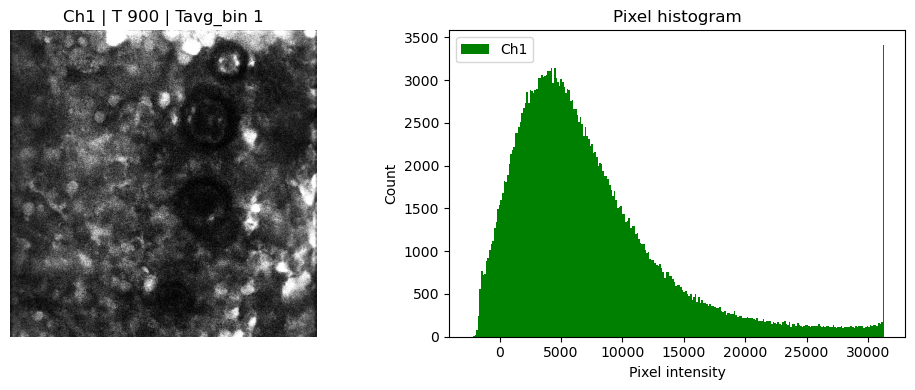

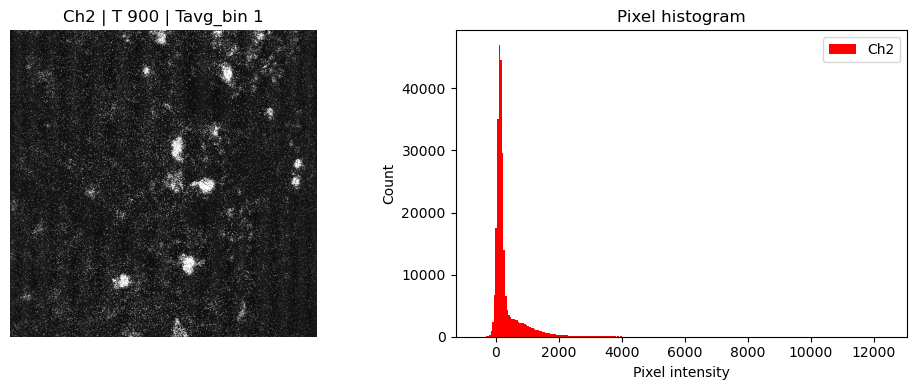

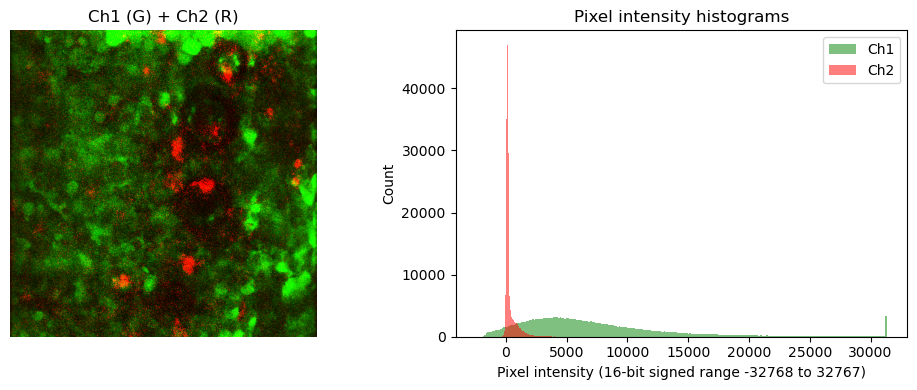

In [103]:
# Sanity check the channels - w/ histograms and ch1+ch2 overlay

# import numpy as np
# import matplotlib.pyplot as plt

def plot_slice_histogram(img, histcolor, zsliceNum=0, frame='Avg', channel='signal'):
    # img = channel_1_data[:, :, frame]
    pixels = img.ravel()
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    # Image
    vmin = np.percentile(img, 1)
    vmax = np.percentile(img, 99)

    axes[0].imshow(img, cmap='gray',
               vmin=vmin,
               vmax=vmax)
    #axes[0].imshow(img, cmap='gray')
    axes[0].set_title(f'{channel} | T {zsliceNum} | Tavg_bin {bin_size}')
    axes[0].axis('off')
    
    # Histogram
    # axes[1].hist(pixels, bins=256, density=True, color=histcolor)
    axes[1].hist(pixels, bins=256, density=False, color=histcolor, label=channel)
    axes[1].set_xlabel('Pixel intensity')
    # axes[1].set_ylabel('Probability density')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Pixel histogram')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

def plot_overlay_and_hist(img1, img2, zsliceNum=0, frame=None,
                          bins=256, alpha=0.5, Saturation=32767):
    """
    img1, img2: (Y, X) arrays for channel 1 and channel 2
    """

    # Build RGB overlay (normalize for display only)
    # def norm(im):
    #     im = im.astype(float)
    #     return (im - im.min()) / (im.max() - im.min() + 1e-9)
    def norm(im, pmin=1, pmax=99):
        im = im.astype(float)
        vmin = np.percentile(im, pmin)
        vmax = np.percentile(im, pmax)
        return np.clip((im - vmin) / (vmax - vmin + 1e-9), 0, 1)

    rgb = np.zeros((*img1.shape, 3))
    rgb[..., 1] = norm(img1)   # green
    rgb[..., 0] = norm(img2)   # red

    # Flatten pixels
    p1 = img1.ravel()
    p2 = img2.ravel()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # ---- Overlay image ----
    axes[0].imshow(rgb)
    title = "Ch1 (G) + Ch2 (R)"
    if zsliceNum is not None and frame is not None:
        title += f" | T {zsliceNum} | Tavg_bin {bin_size}"
    axes[0].set_title(title)
    axes[0].axis('off')

    # ---- Overlaid histograms ----
    axes[1].hist(p1, bins=bins, density=False,
                 color='green', alpha=alpha, label='Ch1')
    axes[1].hist(p2, bins=bins, density=False,
                 color='red', alpha=alpha, label='Ch2')

    axes[1].set_xlabel(f'Pixel intensity (16-bit signed range -32768 to 32767)')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Pixel intensity histograms')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

def preprocess_background(img, bg_pctle=5, norm_pctle=99):
    # perform background subtraction and normalization
    # 1. Keep raw int16 data untouched
    img_raw = img
    
    # 2. Background subtract (robust)
    bg = np.percentile(img_raw, bg_pctle)
    img_bg = img_raw - bg
    
    # 3. (Optional) Normalize to reference
    img_norm = img_bg / np.percentile(img_bg, norm_pctle)

    return img_bg, img_norm

# run the functions here
# frame = 5 # select T frame
# img_chan1 = channel_1_data[:, :, frame]
# img_chan2 = channel_2_data[:, :, frame]

# Need to distinguish Z, T etc explicitlu hehre
img_chan1 = channel_1_data[:, :, tsliceNum]
img_chan2 = channel_2_data[:, :, tsliceNum]

img_chan1_background, img_chan1_normalized = preprocess_background(img_chan1, bg_pctle=5, norm_pctle=99)
img_chan2_background, img_chan2_normalized = preprocess_background(img_chan2, bg_pctle=5, norm_pctle=99)

plot_slice_histogram(img_chan1_background, 'green', tsliceNum, channel='Ch1')
plot_slice_histogram(img_chan2_background, 'red', tsliceNum, channel='Ch2')
plot_overlay_and_hist(img_chan1_background, img_chan2_background,
                      zsliceNum=tsliceNum, frame=None)


In [104]:
print(tif_data.dtype)
print("min:", tif_data.min())
print("max:", tif_data.max())

print(tif_binned.dtype)
print("min:", tif_binned.min())
print("max:", tif_binned.max())

int16
min: -4818
max: 32767
float64
min: -4818.0
max: 32767.0


In [105]:
"""
Notes / knobs you’ll likely tweak

If your Ch2 medians routinely exceed 12k (bright dyes / high gain), bump:

ylim_med_ch2 = (0, 20000) (or 30000)

If your IQR is usually >2000 (dense structure), bump:

ylim_iqr_ch2 = (0, 4000)

If you want the guideline lines to be bands instead of individual lines (shaded zones), I can swap to axhspan().
"""
# QC thresholds (recap, encoded once)
# ---- QC thresholds (int16 ScanImage-style) ----
SAT = 32767

# Median (intensity)
MED_DIM = 500
MED_GOOD_LO, MED_GOOD_HI = 1000, 8000
MED_HOT_HI = 15000

# IQR (contrast / structure)
IQR_LOW = 50
IQR_GOOD_LO, IQR_GOOD_HI = 100, 800
IQR_CEIL = 2000

# Saturation fraction
SAT_WARN = 0.01     # 1%
SAT_BAD  = 0.05     # 5%


In [106]:
# # Helper for guide lines - optional to the final set of plots below
# Basic analysis using median, IQR, and plotting saturation fractions
# More refined analysis comes after
#           - for quick screening/flagging files
#           - impt for quantitative analysis down the road
# def add_guides(a, guides):
#     """
#     guides: list of (y, linestyle, alpha, label)
#     """
#     for y, ls, alpha, label in guides:
#         a.axhline(y, ls=ls, alpha=alpha)
#         if label:
#             a.text(
#                 0.98, y, label,
#                 transform=a.get_yaxis_transform(),
#                 ha="right", va="bottom",
#                 fontsize=8, alpha=0.85
#             )

# # Figure: 3 QC rows + explanation row
# fig, ax = plt.subplots(
#     4, 2,
#     figsize=(13, 11),
#     sharex=True,
#     gridspec_kw={"height_ratios": [1, 1, 1, 0.55]}
# )

# # Row 1 — Median intensity
# ax[0,0].plot(med1, lw=1.8)
# ax[0,1].plot(med2, lw=1.8)

# ax[0,0].set_title("Channel 1 QC (T-avg per Z)")
# ax[0,1].set_title("Channel 2 QC (T-avg per Z)")
# ax[0,0].set_ylabel("Median intensity")

# median_guides = [
#     (MED_DIM, "--", 0.35, "dim"),
#     (MED_GOOD_LO, "-", 0.25, "good lo"),
#     (MED_GOOD_HI, "-", 0.25, "good hi"),
#     (MED_HOT_HI, "--", 0.35, "risky"),
# ]
# # Good median band
# ax[0,0].axhspan(
#     MED_GOOD_LO, MED_GOOD_HI,
#     color='green', alpha=0.08, zorder=0
# )
# ax[0,1].axhspan(
#     MED_GOOD_LO, MED_GOOD_HI,
#     color='green', alpha=0.08, zorder=0
# )


# add_guides(ax[0,0], median_guides)
# add_guides(ax[0,1], median_guides)

# # ax[0,0].set_ylim(0, 12000)
# # ax[0,1].set_ylim(0, 12000)


# # Row 2 — IQR
# ax[1,0].plot(iqr1, lw=1.8)
# ax[1,1].plot(iqr2, lw=1.8)

# ax[1,0].set_ylabel("IQR (Q75–Q25)")

# iqr_guides = [
#     (IQR_LOW, "--", 0.35, "low"),
#     (IQR_GOOD_LO, "-", 0.25, "good lo"),
#     (IQR_GOOD_HI, "-", 0.25, "good hi"),
#     (IQR_CEIL, "--", 0.25, "ceiling"),
# ]
# ax[1,0].axhspan(
#     IQR_GOOD_LO, IQR_GOOD_HI,
#     color='green', alpha=0.08, zorder=0
# )
# ax[1,1].axhspan(
#     IQR_GOOD_LO, IQR_GOOD_HI,
#     color='green', alpha=0.08, zorder=0
# )

# add_guides(ax[1,0], iqr_guides)
# add_guides(ax[1,1], iqr_guides)

# # ax[1,0].set_ylim(0, IQR_CEIL)
# # ax[1,1].set_ylim(0, IQR_CEIL)


# # Row 3 — Saturation fraction (critical)
# ax[2,0].plot(sat1, lw=1.8)
# ax[2,1].plot(sat2, lw=1.8)

# ax[2,0].set_ylabel("Saturation fraction")
# ax[2,0].text(
#     0.02, 0.9, f"SAT = {SAT}",
#     transform=ax[2,0].transAxes,
#     fontsize=9
# )

# # Warning / failure lines
# sat_guides = [
#     (SAT_WARN, "--", 0.5, "warn (1%)"),
#     (SAT_BAD,  "--", 0.7, "bad (5%)"),
# ]

# add_guides(ax[2,0], sat_guides)
# add_guides(ax[2,1], sat_guides)

# # ax[2,0].set_ylim(0, 0.1)
# # ax[2,1].set_ylim(0, 0.1)

# # Shared X, grids, polish
# xmax = Z - 1
# for a in ax[0:3, :].flat:
#     a.set_xlim(0, xmax)
#     a.grid(True, alpha=0.2)

# ax[2,0].set_xlabel("Z index")
# ax[2,1].set_xlabel("Z index")

# # Row 4 — Explanation panel (no axes)
# for c in range(2):
#     ax[3,c].axis("off")

# explain = (
#     "QC interpretation (int16 ScanImage-style)\n"
#     "Median: <500 dim | 1000–8000 good | 8000–15000 hot | >15000 clipping risk\n"
#     "IQR: <50 low contrast/focus | 100–800 healthy structure | >800 very structured\n"
#     "Saturation: >1% warning | >5% unacceptable (power/gain too high)\n"
#     "Best practice: keep fixed axes across files so depth-related failures pop out."
# )

# ax[3,0].text(
#     0.0, 0.95, explain,
#     ha="left", va="top",
#     fontsize=10
# )

# plt.tight_layout()
# plt.show()

In [107]:
"""
How to interpret these (especially for tdTomato)

For a sparse red channel:
"""

"""
Sparse-channel interpretation (important for tdTomato)
Because tdTomato is often sparse:
    p50 (median) mostly reflects background
    p99 and top_mean track structural signal
    > bright_frac is a sensitive detector of area change

If:
p50 stable
p99 fluctuates
→ biological modulation of bright structures.

If:
p50 drifts
p99 stable
→ baseline instability.

What to look for in a T-averaged (60-frame) stack
If you averaged 60 frames:
    Fast noise should be suppressed
    Slow drifts become clearer
    Bleaching trends become easier to quantify
    Transient spikes are smoothed
So trends across T are more likely to represent:
    power drift
    bleaching
    motion band
    biological modulation
    rather than shot noise.
-------------
Per-T, per-channel summary metrics:

Baseline-sensitive
p5 (or p10) → background / offset
p50 → bulk intensity

Signal-sensitive
p95
p99
top_mean (top 0.5% brightest pixels)

Contrast
dr = p99 − p5

Clipping
sat (≥ SAT)
near_sat (≥ SAT − margin)

(For time series: sudden spikes in sat can indicate motion or transient overexposure.)

"""

# import numpy as np
# import matplotlib.pyplot as plt

SAT = 32767

def qc_per_z_extended(channel_idx, *,
                      p_lo=5, p_hi1=95, p_hi2=99,
                      top_frac=0.005,          # top 0.5%
                      near_sat_margin=500,      # counts below SAT
                      bright_thresh_mode="p99"  # "p99" or "p995" or numeric
                     ):
    """
    tif_data expected shape: (Z, T, C, Y, X)
    Returns dict of per-Z metrics.
    """
    Z = tif_data.shape[0]   # ← derive from data, not global
    
    med = np.zeros(Z)
    iqr = np.zeros(Z)
    sat = np.zeros(Z)

    p5 = np.zeros(Z)
    p50 = np.zeros(Z)
    p95 = np.zeros(Z)
    p99 = np.zeros(Z)
    dr = np.zeros(Z)

    near_sat = np.zeros(Z)

    top_mean = np.zeros(Z)
    bright_frac = np.zeros(Z)

    for z in range(Z):
        img = tif_data[z, channel_idx, :, :].mean(axis=0)  # (Y,X)
        px = img.ravel()

        # percentiles
        p5[z]  = np.percentile(px, p_lo)
        p50[z] = np.percentile(px, 50)
        p95[z] = np.percentile(px, p_hi1)
        p99[z] = np.percentile(px, p_hi2)
        dr[z]  = p99[z] - p5[z]

        # legacy metrics (keep)
        med[z] = p50[z]
        iqr[z] = np.percentile(px, 75) - np.percentile(px, 25)
        sat[z] = np.mean(px >= SAT)
        near_sat[z] = np.mean(px >= (SAT - near_sat_margin))

        # top fraction mean (sparse-signal proxy)
        k = max(1, int(np.floor(top_frac * px.size)))
        # partition is faster than full sort
        topk = np.partition(px, -k)[-k:]
        top_mean[z] = np.mean(topk)

        # bright fraction above threshold
        if isinstance(bright_thresh_mode, (int, float)):
            thr = bright_thresh_mode
        else:
            if bright_thresh_mode == "p99":
                thr = p99[z]
            elif bright_thresh_mode == "p995":
                thr = np.percentile(px, 99.5)
            elif bright_thresh_mode == "p999":
                thr = np.percentile(px, 99.9)
            else:
                thr = p99[z]
        bright_frac[z] = np.mean(px > thr)

    return {
        "p5": p5, "p50": p50, "p95": p95, "p99": p99,
        "dr": dr,
        "iqr": iqr,
        "sat": sat, "near_sat": near_sat,
        "top_mean": top_mean,
        "bright_frac": bright_frac,
    }

qc1 = qc_per_z_extended(0)  # Ch1
qc2 = qc_per_z_extended(1)  # Ch2

print(f'Saturation set at {SAT} & quality control function(s) loaded. Run the next cell...')

Saturation set at 32767 & quality control function(s) loaded. Run the next cell...


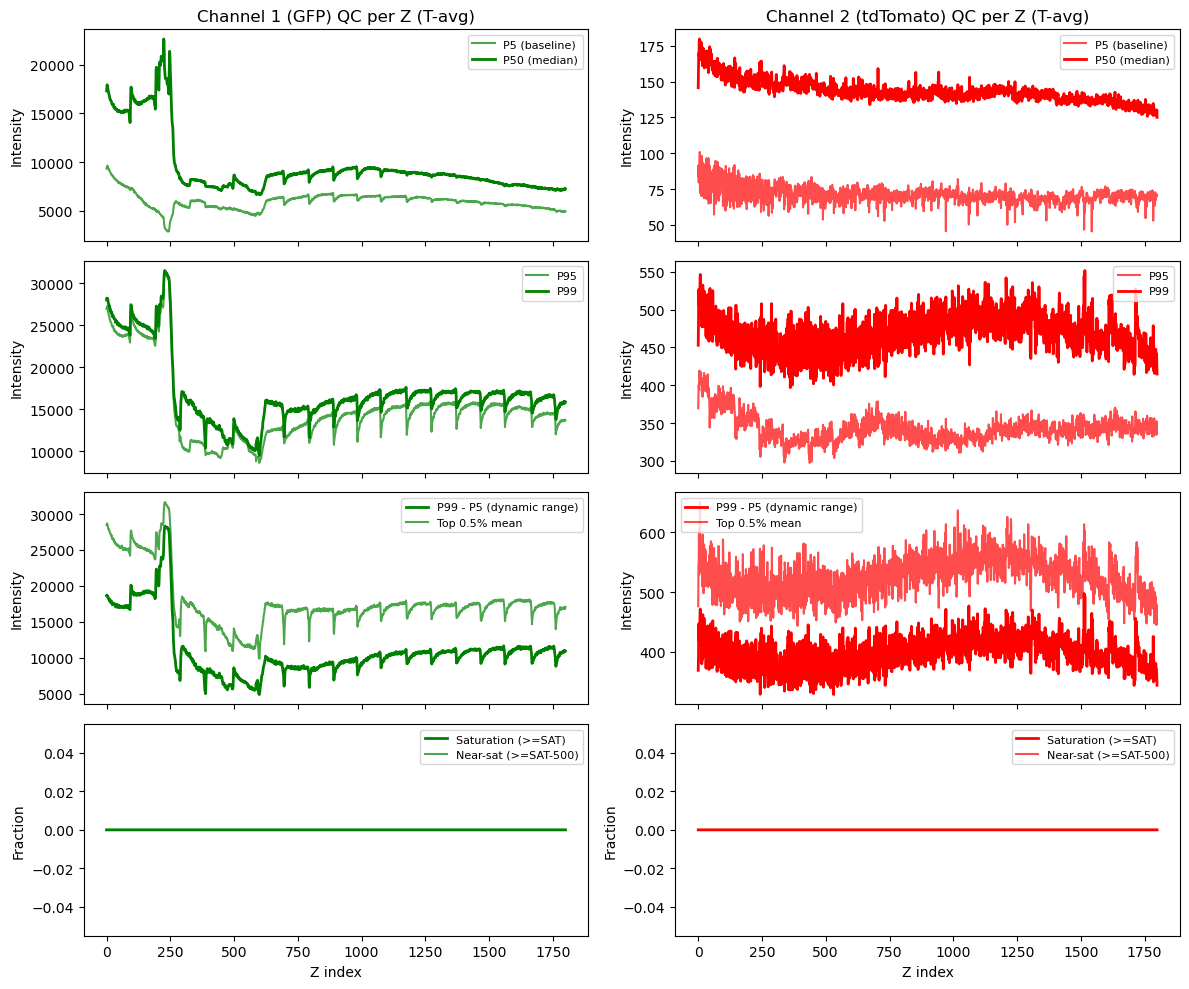

In [108]:
# Plotting: a “high-value” QC figure (4 rows × 2 cols)
# This replaces your 3×2 with something more informative for sparse channels.
fig, ax = plt.subplots(4, 2, figsize=(12, 10), sharex=True)

def plot_channel(col, qc, color, title):
    # Row 1: Baseline + central tendency
    ax[0, col].plot(qc["p5"],  color=color, alpha=0.7, label="P5 (baseline)")
    ax[0, col].plot(qc["p50"], color=color, lw=2, label="P50 (median)")
    ax[0, col].set_title(title)
    ax[0, col].set_ylabel("Intensity")
    ax[0, col].legend(fontsize=8)

    # Row 2: Signal-sensitive percentiles
    ax[1, col].plot(qc["p95"], color=color, alpha=0.7, label="P95")
    ax[1, col].plot(qc["p99"], color=color, lw=2, label="P99")
    ax[1, col].set_ylabel("Intensity")
    ax[1, col].legend(fontsize=8)

    # Row 3: Contrast + sparse-signal proxy
    ax[2, col].plot(qc["dr"],       color=color, lw=2, label="P99 - P5 (dynamic range)")
    ax[2, col].plot(qc["top_mean"], color=color, alpha=0.7, label="Top 0.5% mean")
    ax[2, col].set_ylabel("Intensity")
    ax[2, col].legend(fontsize=8)

    # Row 4: Clipping / saturation
    ax[3, col].plot(qc["sat"],      color=color, lw=2, label="Saturation (>=SAT)")
    ax[3, col].plot(qc["near_sat"], color=color, alpha=0.7, label="Near-sat (>=SAT-500)")
    ax[3, col].set_ylabel("Fraction")
    ax[3, col].set_xlabel("Z index")
    ax[3, col].legend(fontsize=8)

plot_channel(0, qc1, "green", "Channel 1 (GFP) QC per Z (T-avg)")
plot_channel(1, qc2, "red",   "Channel 2 (tdTomato) QC per Z (T-avg)")

plt.tight_layout()
plt.show()

# Match y-lims across channels for each row (like you already do)
for row in range(ax.shape[0]):
    ymins = [ax[row, 0].get_ylim()[0], ax[row, 1].get_ylim()[0]]
    ymaxs = [ax[row, 0].get_ylim()[1], ax[row, 1].get_ylim()[1]]
    ymin, ymax = min(ymins), max(ymaxs)
    ax[row, 0].set_ylim(ymin, ymax)
    ax[row, 1].set_ylim(ymin, ymax)


In [109]:
# Get CSV metadata for ScanImage TXYZ TIF files
# Output image metadata to csv- and/or txt-friendly format

from pathlib import Path
import json
import socket
import platform
import re
import pandas as pd
import tifffile as tiff
from datetime import datetime

def _parse_epoch_line(desc_text: str):
    """
    Parse ScanImage epoch line like:
      epoch = [2026  1 13 16 24 29.809]
    Returns datetime or None.
    """
    if not desc_text:
        return None, None

    m = re.search(r"(?m)^epoch\s*=\s*\[([^\]]+)\]\s*$", desc_text)
    if not m:
        return None, None

    raw = m.group(1).strip()  # "2026  1 13 16 24 29.809"
    parts = [p for p in re.split(r"\s+", raw) if p]
    if len(parts) < 6:
        return None, raw

    y = int(float(parts[0]))
    mo = int(float(parts[1]))
    d = int(float(parts[2]))
    h = int(float(parts[3]))
    mi = int(float(parts[4]))
    sec = float(parts[5])

    sec_int = int(sec)
    usec = int(round((sec - sec_int) * 1e6))
    dt = datetime(y, mo, d, h, mi, sec_int, usec)
    return dt, raw

def _get_si_value(software_text: str, key: str):
    """
    Extract a ScanImage 'SI.key = value' line from the Software tag text.
    Returns the value string (stripped) or None.
    """
    if not software_text:
        return None
    m = re.search(rf"(?m)^{re.escape(key)}\s*=\s*(.*)$", software_text)
    return m.group(1).strip() if m else None

def _parse_si_vector(txt):
    if not txt:
        return None
    s = txt.strip().strip("[]")
    parts = [p for p in s.replace(",", " ").split() if p]
    try:
        return [float(p) for p in parts]
    except ValueError:
        return None

def fov_um_from_tiff_resolution(page):
    tags = page.tags

    # XResolution/YResolution are (num, denom) tuples
    res_x_num, res_x_den = tags["XResolution"].value
    res_y_num, res_y_den = tags["YResolution"].value
    res_x = res_x_num / res_x_den  # pixels per unit
    res_y = res_y_num / res_y_den

    unit = tags["ResolutionUnit"].value  # 2=inches, 3=cm

    height, width = page.shape  # rows, cols

    if unit == 3:  # cm
        width_um  = (width  / res_x) * 1e4
        height_um = (height / res_y) * 1e4
    elif unit == 2:  # inch
        width_um  = (width  / res_x) * 25400
        height_um = (height / res_y) * 25400
    else:
        return None, None, None, None  # unsupported / missing

    um_per_px_x = width_um / width
    um_per_px_y = height_um / height
    
    return width_um, height_um, um_per_px_x, um_per_px_y


def export_scanimage_metadata(tif_path, out_csv=None):
    tif_path = Path(tif_path)

    with tiff.TiffFile(tif_path) as tf:
        p0 = tf.pages[0]
        
        # FOV fallback from TIFF resolution tags (matches what Fiji reports)
        fov_x_um_tiff, fov_y_um_tiff, um_per_pixel_x_tiff, um_per_pixel_y_tiff = fov_um_from_tiff_resolution(p0)


        software = str(p0.tags.get("Software").value) if p0.tags.get("Software") else ""
        artist = str(p0.tags.get("Artist").value) if p0.tags.get("Artist") else ""
        desc = str(p0.tags.get("ImageDescription").value) if p0.tags.get("ImageDescription") else ""

        imaging_fov_um = _get_si_value(software, "SI.hRoiManager.imagingFovUm")

        # ---------- File info ----------
        stat = tif_path.stat()
        file_created = datetime.fromtimestamp(stat.st_ctime)
        file_modified = datetime.fromtimestamp(stat.st_mtime)

        # ---------- Acquisition epoch -> datetime ----------
        acq_dt, acq_epoch_raw = _parse_epoch_line(desc)

        # # ---------- ROI geometry (Artist tag JSON) ----------
        # fov_x_um = fov_y_um = px_x = px_y = None
        # scan_zoom_factor = None
        # try:
        #     roi_root = json.loads(artist)
        #     roi = roi_root["RoiGroups"]["imagingRoiGroup"]["rois"]
        #     scanfield = roi["scanfields"]
        #     # fov_x_um, fov_y_um = scanfield["sizeXY"]
        #     fov_xy = _parse_si_vector(imaging_fov_um)

        #     if fov_xy and len(fov_xy) == 2:
        #         fov_x_um, fov_y_um = fov_xy
        #         um_per_pixel_x = fov_x_um / px_x
        #         um_per_pixel_y = fov_y_um / px_y
        #     else:
        #         fov_x_um = fov_y_um = um_per_pixel_x = um_per_pixel_y = None

        #     px_x, px_y = scanfield["pixelResolutionXY"]
        #     scan_zoom_factor = roi.get("UserData", {}).get("scanZoomFactor", None)

        # except Exception:
        #     # If Artist isn't valid JSON, just leave these as None
        #     pass
        # ---------- ROI geometry (Artist tag JSON) ----------
        fov_x_um = fov_y_um = px_x = px_y = None
        um_per_pixel_x = um_per_pixel_y = None
        scan_zoom_factor = None
        
        try:
            roi_root = json.loads(artist)
            roi = roi_root["RoiGroups"]["imagingRoiGroup"]["rois"]
            scanfield = roi["scanfields"]
        
            # pixel dims (needed for um/px)
            px_x, px_y = scanfield["pixelResolutionXY"]
        
            # calibrated FOV from Software tag (preferred)
            fov_xy = _parse_si_vector(imaging_fov_um)
            if fov_xy and len(fov_xy) == 2 and px_x and px_y:
                fov_x_um, fov_y_um = fov_xy
                um_per_pixel_x = fov_x_um / px_x
                um_per_pixel_y = fov_y_um / px_y
        
            scan_zoom_factor = roi.get("UserData", {}).get("scanZoomFactor", None)
        
        except Exception:
            pass
            
        # Fallback if ScanImage FOV is missing
        if fov_x_um is None and fov_x_um_tiff is not None:
            fov_x_um = fov_x_um_tiff
            fov_y_um = fov_y_um_tiff
            um_per_pixel_x = um_per_pixel_x_tiff
            um_per_pixel_y = um_per_pixel_y_tiff
            fov_source = "tiff_resolution_tags"
        else:
            fov_source = "scanimage_imagingFovUm" if fov_x_um is not None else "missing"

        # ---------- Basic image geometry from TIFF page ----------
        # tifffile pages have shape, but tags are reliable:
        image_width_px = getattr(p0, "imagewidth", None)
        image_height_px = getattr(p0, "imagelength", None)

        # imaging_fov_um = _get_si_value(software, "SI.hRoiManager.imagingFovUm")

        # ---------- ScanImage version / files ----------
        ver_major = _get_si_value(software, "SI.VERSION_MAJOR")
        ver_minor = _get_si_value(software, "SI.VERSION_MINOR")
        ver_update = _get_si_value(software, "SI.VERSION_UPDATE")

        scanimage_version = None
        if ver_major and ver_minor and ver_update:
            scanimage_version = f"{ver_major}.{ver_minor}.{ver_update}"

        # ---------- Channels / optics ----------
        channels_saved = _get_si_value(software, "SI.hChannels.channelSave")
        channel_names = _get_si_value(software, "SI.hChannels.channelName")
        frame_rate_hz = _get_si_value(software, "SI.hRoiManager.scanFrameRate")

        # NOTE: In your screenshot + file dump, laser wavelength is from the laser UI,
        # but ScanImage often stores it as part of beam "powers" or separate fields depending on integration.
        # We'll still report beam powers & power fractions when present.
        beam_power_mw = _get_si_value(software, "SI.hBeams.powers")
        beam_power_fraction = _get_si_value(software, "SI.hBeams.powerFractions")

        # PMT gains are controller-specific; may be missing in some configs
        pmt_gains = _get_si_value(software, "SI.hPmts.gain")
        pmt_offsets = _get_si_value(software, "SI.hChannels.channelOffset")

        # ---------- Scanner type ---------- #begin_new1
        scanner_name = (_get_si_value(software, "SI.hScan2D.scannerType")
                        or _get_si_value(software, "SI.hScan2D.name"))
        scanner_resonant = _get_si_value(software, "SI.hScan2D.resonantScannerEnable")
        # scanner_bidirectional = _get_si_value(software, "SI.hScan2D.bidirectionalScan")
        line_rate_hz = _get_si_value(software, "SI.hScan2D.scanLineRate")

        # Scanner classification
        scanner_resonant_enabled = (scanner_name == "'RGG'")
        
        # Resonant scanners are inherently bidirectional
        scanner_bidirectional = True if scanner_resonant_enabled else _get_si_value(
            software, "SI.hScan2D.bidirectionalScan"
        )
        
        # Line rate is not logged for resonant scanners
        scan_line_rate_hz = None
        scan_line_rate_note = (
            "Resonant scanner line rate is hardware-defined and not written to TIFF metadata"
            if scanner_resonant_enabled else "Derived from ScanImage metadata"
        )
        # Can manually derive from fps value and pixels
        512/30
        Out[2]: 17.066666666666666
        
        17.067*30
        Out[5]: 512.01
        
        17.0667*512
        Out[6]: 8738.1504
        
        # ---------- Pockels / power ----------
        pockels_power_fractions = _get_si_value(software, "SI.hBeams.powerFractions")
        pockels_power_limits = _get_si_value(software, "SI.hBeams.powerFractionLimits")
        pockels_lut_source = _get_si_value(software, "SI.hBeams.pzLUTSource")
        pockels_pz_adjust = _get_si_value(software, "SI.hBeams.pzAdjust")
        pockels_flyback_blanking = _get_si_value(software, "SI.hBeams.flybackBlanking")
        pockels_turnaround_blanking = _get_si_value(software, "SI.hBeams.turnAroundBlanking")
        
        # If your config logs absolute mW in SI.hBeams.powers, keep that too:
        beam_powers_mw = _get_si_value(software, "SI.hBeams.powers")
        
        # ---------- PMT values ----------
        # Gains are sometimes here; offsets often under hChannels
        pmt_gains = (_get_si_value(software, "SI.hPmts.gain")
                     or _get_si_value(software, "SI.hPmts.gains"))
        pmt_offsets = (_get_si_value(software, "SI.hChannels.channelOffset")
                       or _get_si_value(software, "SI.hPmts.offset"))
        
        # ---------- Frames averaged / averaging ----------
        # Display rolling average is NOT acquisition averaging; you want these when present:
        log_avg_enable = _get_si_value(software, "SI.hScan2D.logAverageEnable")
        log_avg_factor = _get_si_value(software, "SI.hScan2D.logAverageFactor")
        
        # Also useful: scan/recording averaging modes can vary across versions:
        # (These might not exist in every config; safe to keep.)
        scan_avg_enable = _get_si_value(software, "SI.hScan2D.scanAverageEnable")
        scan_avg_factor = _get_si_value(software, "SI.hScan2D.scanAverageFactor") #end new1

        # Objective name exists only if the objective manager is configured
        objective_name = _get_si_value(software, "SI.hObjectiveManager.objectiveName")

        # ---------- TIFF structure ----------
        num_frames = len(tf.pages)
        timestamps_present = "frameTimestamps_sec" in desc

        # ---------- Derived um/px ----------
        um_per_pixel_x = (float(fov_x_um) / float(px_x)) if (fov_x_um and px_x) else None
        um_per_pixel_y = (float(fov_y_um) / float(px_y)) if (fov_y_um and px_y) else None

        row = {
            # File / identity
            "filename": tif_path.name,
            "full_path": str(tif_path),
            "file_size_mb": round(stat.st_size / 1e6, 2),
            "file_created_time": file_created.isoformat(),
            "file_modified_time": file_modified.isoformat(),
            "acquisition_datetime": acq_dt.isoformat() if acq_dt else None,
            "acquisition_epoch_raw": acq_epoch_raw,
            "scanimage_version": scanimage_version,
            "scanimage_commit": _get_si_value(software, "SI.VERSION_COMMIT"),
            "scanimage_premium": _get_si_value(software, "SI.PREMIUM"),
            "config_file": _get_si_value(software, "SI.hConfigurationSaver.cfgFilename"),
            "user_file": _get_si_value(software, "SI.hConfigurationSaver.usrFilename"),
            "host_os": platform.platform(),
            "host_machine": socket.gethostname(),
            "fov_source": fov_source,

            # Image geometry
            "pixels_per_line": px_x,
            "lines_per_frame": px_y,
            "image_width_px": image_width_px,
            "image_height_px": image_height_px,
            "fov_x_um": fov_x_um,
            "fov_y_um": fov_y_um,
            "um_per_pixel_x": um_per_pixel_x,
            "um_per_pixel_y": um_per_pixel_y,

            # Acquisition structure
            "num_frames": num_frames,
            "frame_rate_hz": frame_rate_hz,
            "timestamps_present": timestamps_present,
            "channels_saved": channels_saved,
            "channel_names": channel_names,
            "bit_depth": p0.bitspersample if hasattr(p0, "bitspersample") else None,
            "samples_per_pixel": getattr(p0, "samplesperpixel", None),
            "planar_configuration": getattr(p0, "planarconfiguration", None),

            # Scanner
            # "scanner_name": scanner_name,
            # "scanner_resonant_enabled": scanner_resonant,
            # "scanner_bidirectional": scanner_bidirectional,
            # "scan_line_rate_hz": line_rate_hz,
            "scanner_name": scanner_name,
            "scanner_resonant_enabled": scanner_resonant_enabled,
            "scanner_bidirectional": scanner_bidirectional,
            "scan_line_rate_hz": scan_line_rate_hz,
            "scan_line_rate_note": scan_line_rate_note,
            
            # Pockels / power
            "pockels_power_fractions": pockels_power_fractions,
            "pockels_power_limits": pockels_power_limits,
            "pockels_lut_source": pockels_lut_source,
            "pockels_pz_adjust": pockels_pz_adjust,
            "pockels_flyback_blanking": pockels_flyback_blanking,
            "pockels_turnaround_blanking": pockels_turnaround_blanking,
            "beam_powers_mw": beam_powers_mw,
            
            # PMTs
            "pmt_gains": pmt_gains,
            "pmt_offsets": pmt_offsets,
            
            # Averaging (acquisition/log averaging when present)
            "log_avg_enable": log_avg_enable,
            "log_avg_factor": log_avg_factor,
            "scan_avg_enable": scan_avg_enable,
            "scan_avg_factor": scan_avg_factor,

            # Optics / laser
            "objective_name": objective_name,
            "scan_zoom_factor": scan_zoom_factor,
            "beam_power_mw": beam_power_mw,
            "beam_power_fraction": beam_power_fraction,
            "pmt_offsets": pmt_offsets,
            "pmt_gains": pmt_gains,

            # Z semantics (explicit & honest)
            "acquisition_type": "single_plane",
            "z_logged": "no",
            "z_reference": "roi_relative_zero",
            "z_note": "Single-plane T-series; no StackManager/FastZ Z positions logged into TIFF",
        }

    print("TIFF resolution tags FOV:", fov_x_um_tiff, "*", fov_y_um_tiff, "um;", "um/px:", "x=", um_per_pixel_x_tiff, "y=", um_per_pixel_y_tiff)
    
    print('   ')
    print('*** A new CSV file should appear in the source-file (ie TIF) directory ***')    
    
    df = pd.DataFrame([row])

    df_kv = df.T.reset_index()
    df_kv.columns = ["field", "value"]


    if out_csv is None:
        out_csv = tif_path.with_suffix("").as_posix() + "_metadata.csv"
    df_kv.to_csv(out_csv, index=False)
    return df_kv

print("Function loaded, ready to run def(export_scanimage_metadata)...")

Function loaded, ready to run def(export_scanimage_metadata)...


In [110]:
print(tif_filename1)

export_scanimage_metadata(
    tif_file1
)

# Notes  remember that 'num_frames' will represent 2 channels
# so the actual frames_per_chan = num_frames/channels_saved
# (eg if 1800 frames were acquired per channel, num_frames=3600 and channels_saved=2; frames_per_chan = num_frames/2)

T1800_25x3x_930nm_area07_00001.tif
TIFF resolution tags FOV: 162.99724578857422 * 162.99724578857422 um; um/px: x= 0.318353995680809 y= 0.318353995680809
   
*** A new CSV file should appear in the source-file (ie TIF) directory ***


,field,value
0,filename,T1800_25x3x_930nm_area07_00001.tif
1,full_path,/Users/jcoleman/Documents/--LARGE DATA--/#VonR...
2,file_size_mb,1896.04
3,file_created_time,2026-01-15T18:47:39.432048
4,file_modified_time,2026-01-15T16:10:40
5,acquisition_datetime,2026-01-15T16:09:39.981000
6,acquisition_epoch_raw,2026 1 15 16 9 39.981
7,scanimage_version,2023.1.1
8,scanimage_commit,'6fa08573b737b7ca5870c37cdb5781839365bdf6'
9,scanimage_premium,true


In [111]:
print(tif_filename2)

export_scanimage_metadata(
    tif_file2
)

T1800_25x3x_1100nm_area07_00001.tif
TIFF resolution tags FOV: 162.99724578857422 * 162.99724578857422 um; um/px: x= 0.318353995680809 y= 0.318353995680809
   
*** A new CSV file should appear in the source-file (ie TIF) directory ***


,field,value
0,filename,T1800_25x3x_1100nm_area07_00001.tif
1,full_path,/Users/jcoleman/Documents/--LARGE DATA--/#VonR...
2,file_size_mb,1896.04
3,file_created_time,2026-01-15T18:48:04.901153
4,file_modified_time,2026-01-15T16:12:58
5,acquisition_datetime,2026-01-15T16:11:56.130000
6,acquisition_epoch_raw,2026 1 15 16 11 56.130
7,scanimage_version,2023.1.1
8,scanimage_commit,'6fa08573b737b7ca5870c37cdb5781839365bdf6'
9,scanimage_premium,true


In [113]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy import signal

# def detrend_moving_average(x, win):
#     x = np.asarray(x, float)
#     ma = signal.convolve(x, np.ones(win)/win, mode="same")
#     return x - ma

# def welch_psd(x, fs, nperseg=None):
#     x = np.asarray(x, float)
#     x = signal.detrend(x)  # removes linear trend
#     f, Pxx = signal.welch(x, fs=fs, nperseg=nperseg or min(256, len(x)))
#     return f, Pxx

# def top_peaks(f, Pxx, n=5, fmin=0.01, fmax=20):
#     mask = (f >= fmin) & (f <= fmax)
#     ff, pp = f[mask], Pxx[mask]
#     pk, props = signal.find_peaks(pp, prominence=np.max(pp)*0.02)
#     order = np.argsort(pp[pk])[::-1][:n]
#     return list(zip(ff[pk][order], pp[pk][order]))

# # Example usage:
# # x = top_mean_red  # 1D array over T bins
# # fs = 0.5          # Hz (example)
# # x_d = detrend_moving_average(x, win=15)
# # f, P = welch_psd(x_d, fs)
# # print("Top peaks (Hz, power):", top_peaks(f, P))

# def plot_spectrogram_with_trace(x, fs,
#                                  nperseg=256,
#                                  noverlap=200,
#                                  fmax=15,
#                                  cmap="magma"):

#     x = np.asarray(x, float)
#     x = signal.detrend(x)

#     # Compute STFT
#     f, t, Sxx = signal.spectrogram(
#         x,
#         fs=fs,
#         nperseg=nperseg,
#         noverlap=noverlap,
#         scaling='density',
#         mode='psd'
#     )

#     # Limit frequency range
#     mask = f <= fmax
#     f = f[mask]
#     Sxx = Sxx[mask, :]

#     # Convert to dB for better visibility
#     Sxx_db = 10 * np.log10(Sxx + 1e-12)

#     # ---- Plot ----
#     fig = plt.figure(figsize=(10, 7))

#     # Top: signal trace
#     ax1 = plt.subplot(2,1,1)
#     time = np.arange(len(x)) / fs
#     ax1.plot(time, x, color="black", linewidth=1)
#     ax1.set_ylabel("Signal")
#     ax1.set_title("Signal Trace")

#     # Bottom: spectrogram
#     ax2 = plt.subplot(2,1,2, sharex=ax1)
#     im = ax2.pcolormesh(t, f, Sxx_db,
#                         shading='gouraud',
#                         cmap=cmap)
#     ax2.set_ylabel("Frequency (Hz)")
#     ax2.set_xlabel("Time (s)")
#     ax2.set_title("Power Spectrogram")

#     plt.colorbar(im, ax=ax2, label="Power (dB)")

#     plt.tight_layout()
#     plt.show()

#     return f, t, Sxx_db

# # NOTE: Only run this section when your 'bin_size=1 (ie raw T w/ no averaging for higher fs @ 30fps)
# x=qc1['top_mean']
# fs = 30         # Hz (example)
# x_d = detrend_moving_average(x, win=15)
# f, P = welch_psd(x_d, fs)
# print("Top peaks (Hz, power):", top_peaks(f, P))
# # plt.plot(x)

# plot_spectrogram_with_trace(x, fs,
#                                  nperseg=256,
#                                  noverlap=200,
#                                  fmax=15,
#                                  cmap="magma")

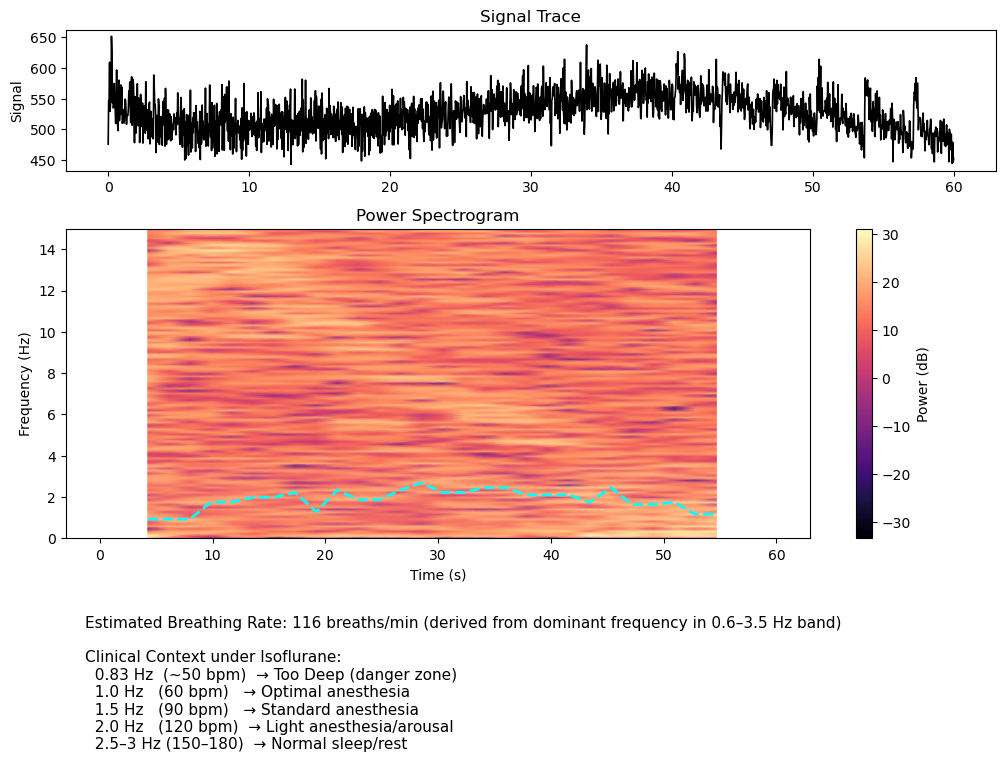

Estimated BPM: 49.21875


In [121]:
# NOTE: Only run this section when your 'bin_size=1 (ie raw T w/ no averaging for higher fs @ 30fps)
"""
Run this to inspect large drifts and spikes in signals - still experimental
Rough guide for monitoring breathing rate from image spikes
- As a general monitoring window. 1–2 Hz (60–120 bpm) is the standard range for anesthesia.

"""

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

def plot_clean_breathing_qc(
    x, fs,
    bad_idx=None,
    nperseg=256,
    noverlap=200,
    fmax=15,
    breath_band_hz=(0.6, 3.5),
    bpm_summary="median"
):

    x = np.asarray(x, float)
    time = np.arange(len(x)) / fs
    x_d = signal.detrend(x)

    # Spectrogram
    f, t, Sxx = signal.spectrogram(
        x_d, fs=fs,
        nperseg=nperseg,
        noverlap=noverlap,
        scaling='density',
        mode='psd'
    )

    mask = f <= fmax
    f = f[mask]
    Sxx = Sxx[mask]
    Sxx_db = 10*np.log10(Sxx + 1e-12)

    # Breathing band dominant frequency
    f_lo, f_hi = breath_band_hz
    mb = (f >= f_lo) & (f <= f_hi)
    band_f = f[mb]
    band_S = Sxx[mb, :]
    idx = np.argmax(band_S, axis=0)
    breath_freq_t = band_f[idx]
    breath_bpm_t = 60 * breath_freq_t
    bpm_est = float(np.median(breath_bpm_t))

    # ---- Layout ----
    fig = plt.figure(figsize=(12, 9))
    gs = fig.add_gridspec(3, 1, height_ratios=[1, 2.2, 0.9], hspace=0.3)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
    ax3 = fig.add_subplot(gs[2, 0])
    ax3.axis("off")

    # =========================
    # TOP: SIGNAL TRACE
    # =========================
    ax1.plot(time, x, color="black", linewidth=1.2)
    ax1.set_ylabel("Signal")
    ax1.set_title("Signal Trace")

    # Red shaded spike zones
    if bad_idx is not None and len(bad_idx) > 0:
        spike_times = bad_idx / fs
        pad = 0.15  # seconds of shading on each side
        for st in spike_times:
            ax1.axvspan(st - pad, st + pad,
                        color='red', alpha=0.15)

    # =========================
    # MIDDLE: SPECTROGRAM
    # =========================
    im = ax2.pcolormesh(
        t, f, Sxx_db,
        shading='gouraud',
        cmap='magma'
    )

    # Cyan breathing-dominant line
    ax2.plot(
        t, breath_freq_t,
        linestyle='--',
        linewidth=2,
        color='cyan'
    )

    # Light shaded breathing band
    ax2.axhspan(f_lo, f_hi, color='white', alpha=0.05)

    ax2.set_ylim(0, fmax)
    ax2.set_ylabel("Frequency (Hz)")
    ax2.set_xlabel("Time (s)")
    ax2.set_title("Power Spectrogram")

    cbar = fig.colorbar(im, ax=ax2)
    cbar.set_label("Power (dB)")

    # =========================
    # BOTTOM: CONTEXT PANEL
    # =========================

    clinical_text = (
        f"Estimated Breathing Rate: {bpm_est:.0f} breaths/min "
        f"(derived from dominant frequency in {f_lo:.1f}–{f_hi:.1f} Hz band)\n\n"
        "Clinical Context under Isoflurane:\n"
        "  0.83 Hz  (~50 bpm)  → Too Deep (danger zone)\n"
        "  1.0 Hz   (60 bpm)   → Optimal anesthesia\n"
        "  1.5 Hz   (90 bpm)   → Standard anesthesia\n"
        "  2.0 Hz   (120 bpm)  → Light anesthesia/arousal\n"
        "  2.5–3 Hz (150–180)  → Normal sleep/rest"
    )

    ax3.text(
        0.02, 0.85,
        clinical_text,
        fontsize=11,
        va='top'
    )

    plt.show()

    return bpm_est

# If you want it to auto-find spikes (per session)
# x=qc1['top_mean']
# fs = 30         # Hz (example)
plot_clean_breathing_qc(
    x=qc2['top_mean'], fs=30,
    bad_idx=None,
    nperseg=256,
    noverlap=200,
    fmax=15,
    breath_band_hz=(0.6, 3.5),
    bpm_summary="median"
)

print(f'Estimated BPM: {out["bpm_est"]}')

In [ ]:
# FUTURE: - Save data CSV, NPZ and/or PKL
#         - Read in metadata from accompanying NPZ for PKL file(s)

In [118]:
import numpy as np
from scipy import signal

def mad(x):
    x = np.asarray(x, float)
    m = np.nanmedian(x)
    return np.nanmedian(np.abs(x - m))

def detect_toothy_motion_spikes(
    x, fs,
    smooth_win_s=1.0,     # trend window (sec)
    poly=3,
    zthr=6.0,             # higher = fewer detections
    min_dist_s=0.6,       # minimum separation between spikes (sec)
    pad_s=0.15,           # expand mask around each spike (sec)
    merge_gap_s=0.25,     # merge close intervals (sec)
):
    """
    Detect sharp 'toothy' motion spikes (usually dips) in a 1D trace.
    Returns: bad_idx, Tmask, intervals, diag
    """
    x = np.asarray(x, float)
    T = len(x)

    # 1) Smooth trend
    win = int(round(smooth_win_s * fs))
    win = max(win, poly + 2)
    if win % 2 == 0:
        win += 1
    x_smooth = signal.savgol_filter(x, window_length=win, polyorder=poly, mode="interp")

    # 2) Residual (high-frequency-ish)
    r = x - x_smooth

    # 3) Robust thresholding on negative spikes: detect peaks in -r
    a = -r
    s = 1.4826 * mad(a) + 1e-12
    a_z = (a - np.nanmedian(a)) / s

    # Peak find: enforce min distance between spikes
    min_dist = int(round(min_dist_s * fs))
    peaks, props = signal.find_peaks(a_z, height=zthr, distance=max(1, min_dist))

    # 4) Convert peaks to intervals with padding
    pad = int(round(pad_s * fs))
    intervals = []
    for p in peaks:
        i0 = max(0, p - pad)
        i1 = min(T - 1, p + pad)
        intervals.append((i0, i1))

    # 5) Merge close intervals
    if intervals:
        intervals.sort()
        merged = [intervals[0]]
        merge_gap = int(round(merge_gap_s * fs))
        for a0, a1 in intervals[1:]:
            b0, b1 = merged[-1]
            if a0 <= b1 + merge_gap:
                merged[-1] = (b0, max(b1, a1))
            else:
                merged.append((a0, a1))
        intervals = merged

    # 6) Build mask
    bad = np.zeros(T, dtype=bool)
    for a0, a1 in intervals:
        bad[a0:a1+1] = True

    bad_idx = np.where(bad)[0]
    Tmask = ~bad

    diag = {
        "x_smooth": x_smooth,
        "resid": r,
        "spike_score": a_z,
        "peaks": peaks
    }
    return bad_idx, Tmask, intervals, diag


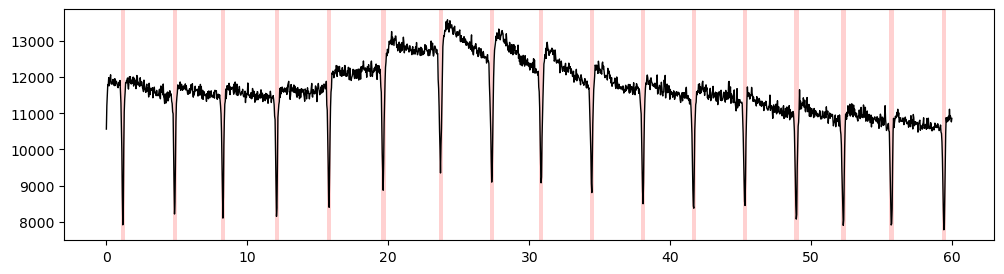

In [119]:
import matplotlib.pyplot as plt

def shade_intervals(ax, intervals, fs, alpha=0.18):
    for a0, a1 in intervals:
        ax.axvspan(a0/fs, (a1+1)/fs, color="red", alpha=alpha, linewidth=0)

# Example:
# bad_idx, Tmask, intervals, diag = detect_toothy_motion_spikes(x, fs=30)
# fig, ax = plt.subplots(figsize=(12,3))
# t = np.arange(len(x))/30
# ax.plot(t, x, color="black", lw=1)
# shade_intervals(ax, intervals, fs=30)
# plt.show()

fs=30
bad_idx, Tmask, intervals, diag = detect_toothy_motion_spikes(x, fs=fs)
fig, ax = plt.subplots(figsize=(12,3))
t = np.arange(len(x))/fs
ax.plot(t, x, color="black", lw=1)
shade_intervals(ax, intervals, fs=fs)
plt.show()


In [120]:
bad_idx

array([  31,   32,   33,   34,   35,   36,   37,   38,   39,  141,  142,
        143,  144,  145,  146,  147,  148,  149,  244,  245,  246,  247,
        248,  249,  250,  251,  252,  358,  359,  360,  361,  362,  363,
        364,  365,  366,  470,  471,  472,  473,  474,  475,  476,  477,
        478,  585,  586,  587,  588,  589,  590,  591,  592,  593,  707,
        708,  709,  710,  711,  712,  713,  714,  715,  816,  817,  818,
        819,  820,  821,  822,  823,  824,  921,  922,  923,  924,  925,
        926,  927,  928,  929, 1029, 1030, 1031, 1032, 1033, 1034, 1035,
       1036, 1037, 1138, 1139, 1140, 1141, 1142, 1143, 1144, 1145, 1146,
       1246, 1247, 1248, 1249, 1250, 1251, 1252, 1253, 1254, 1355, 1356,
       1357, 1358, 1359, 1360, 1361, 1362, 1363, 1464, 1465, 1466, 1467,
       1468, 1469, 1470, 1471, 1472, 1564, 1565, 1566, 1567, 1568, 1569,
       1570, 1571, 1572, 1666, 1667, 1668, 1669, 1670, 1671, 1672, 1673,
       1674, 1778, 1779, 1780, 1781, 1782, 1783, 17